# PINNs: ODE damped oscillator

$$
\begin{cases}
    0 = \ddot{x} + 2\zeta\omega.\dot{x} + \omega^2.x \\
    x(0) = x_0 \\
    \dot{x}(0) = 0
\end{cases}
$$

Solution: (underdamped, $\zeta < 1$)



In [1]:
# imports
# torch
import torch
import torch.nn as nn
import torch.optim as optim

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [2]:
# Define the PINN model
class PINN(nn.Module):

    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

        # equation parameters
        self.ZETTA = 0.2
        self.W = 10

    def forward(self, t):
        return self.net(t)

    # Define the Poisson equation loss function
    def damped_oscillatior_loss(self, t):
        # alias to simplify notation
        # parameters
        ZETTA = self.ZETTA
        W = self.W
        
        # compute estimation for position
        x = self.forward(t)

        # compute derivatives of first and second order
        x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
        x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]

        # residue for damped oscillator
        f = (x_tt + (2*ZETTA*W)*x_t + (W**2)*x)**2
        return torch.mean(f)
    
    def boundary_condition_loss(self, t0, x0, dx0):

        # estimation for x0
        x0_est = self.forward(t0)

        # residue for x0
        initial_conditions = (x0_est - x0)**2

        # estimation for dx0
        dx0_est = torch.autograd.grad(x0_est, t0, grad_outputs=torch.ones_like(x0_est), create_graph=True)[0]

        # residue for dx0
        initial_conditions_der = (dx0_est - dx0)**2


        return torch.mean(initial_conditions) + torch.mean(initial_conditions_der)
            # (-0.0629 - model(torch.tensor([0.4848])))**2 + \
            # (-0.5183 - model(torch.tensor([0.3030])))**2 + \
            # (0.2595 - model(torch.tensor([0.6061])))**2

    def data_loss(self, x, x_est):
        return nn.MSELoss()(x, x_est)


# Define general NN model with same architecture as PINN
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

    def data_loss(self, x, x_est):
        return nn.MSELoss()(x, x_est)

In [3]:
#ne = NN()
#print(ne(t).sum())

In [4]:
# Training data

# domain data
t = 2*torch.rand(100, 1)  # Randomly sampled points in [0, 2]
t.requires_grad = True

# initial conditions
t0 = torch.tensor([0.0], requires_grad=True)
x0_nn = torch.tensor([1.0], requires_grad=True)
x0 = torch.tensor([1.0], requires_grad=True)
dx0 = torch.tensor([0.0], requires_grad=True)

# Create NN and PINN model
nn_model= NN()
pinn_model = PINN()

nn_optimizer = optim.Adam(params=nn_model.parameters(), lr=1e-3)
pinn_optimizer = optim.Adam(params=pinn_model.parameters(), lr=1e-3)

# loss tracking
losses = []

# Training loop
epochs = 60000


# Labeled training data

# random training data
t_sample_nn = 1*torch.rand(100, 1)
t_sample_nn.requires_grad = False

# convenient alias
Z = pinn_model.ZETTA
w = pinn_model.W

# data
root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_sample_nn = x0_nn*torch.exp(-w*Z*t_sample_nn)*(torch.cosh(w*root*t_sample_nn) + (Z/root)*torch.sinh(w*root*t_sample_nn))
x_sample_nn = x_sample_nn.real # get rid of aprox. complex values
#x_sample_nn.requires_grad = False

# random training data
t_sample_pinn = 1*torch.rand(100, 1)
t_sample_pinn.requires_grad = False

# convenient alias
Z = pinn_model.ZETTA
w = pinn_model.W

# data
root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_sample_pinn = x0*torch.exp(-w*Z*t_sample_pinn)*(torch.cosh(w*root*t_sample_pinn) + (Z/root)*torch.sinh(w*root*t_sample_pinn))
x_sample_pinn = x_sample_pinn.real # get rid of aprox. complex values

In [5]:
# testing data

# alias to simplify notation
Z = pinn_model.ZETTA
w = pinn_model.W

# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
x_test = pinn_model(t_test)

root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = x0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real



Epoch [0/60000], NN Loss: 0.15721336007118225
Epoch [0/60000], PINN Loss: 32.90476989746094


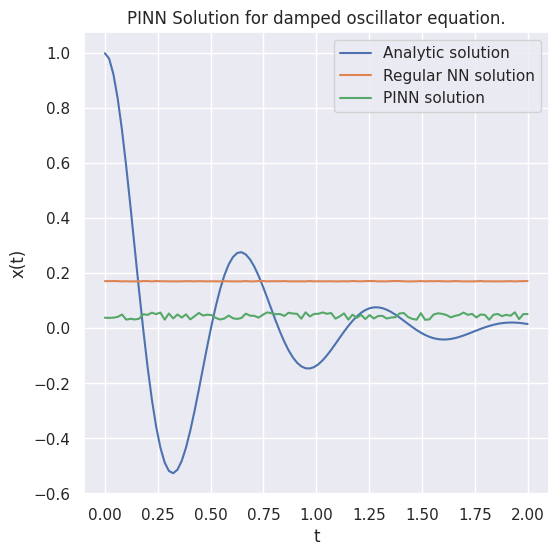

Epoch [1000/60000], NN Loss: 0.00014074773935135454
Epoch [1000/60000], PINN Loss: 1.1714160442352295
Epoch [2000/60000], NN Loss: 3.5945729905506596e-05
Epoch [2000/60000], PINN Loss: 1.1713628768920898
Epoch [3000/60000], NN Loss: 2.339087222935632e-05
Epoch [3000/60000], PINN Loss: 1.1713032722473145
Epoch [4000/60000], NN Loss: 8.891271136235446e-06
Epoch [4000/60000], PINN Loss: 1.171278953552246
Epoch [5000/60000], NN Loss: 4.815933152713114e-06
Epoch [5000/60000], PINN Loss: 1.233330249786377
Epoch [6000/60000], NN Loss: 3.6870326312055113e-06
Epoch [6000/60000], PINN Loss: 1.1712242364883423
Epoch [7000/60000], NN Loss: 2.9705072392971488e-06
Epoch [7000/60000], PINN Loss: 1.171212911605835
Epoch [8000/60000], NN Loss: 2.397487151029054e-06
Epoch [8000/60000], PINN Loss: 1.1712716817855835
Epoch [9000/60000], NN Loss: 6.410099740605801e-05
Epoch [9000/60000], PINN Loss: 1.1712547540664673
Epoch [10000/60000], NN Loss: 1.6268933222818305e-06
Epoch [10000/60000], PINN Loss: 1.175

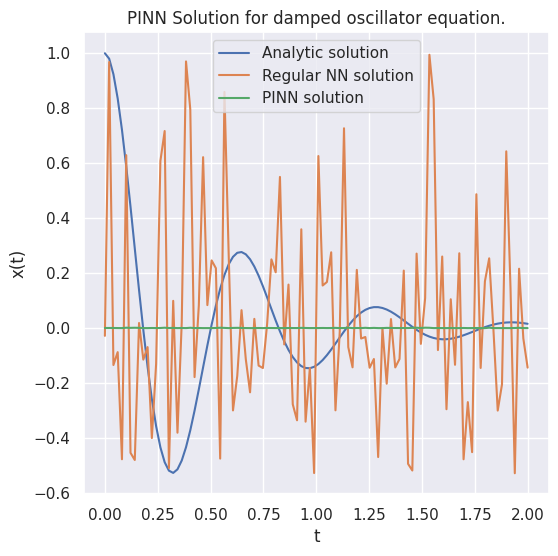

Epoch [11000/60000], NN Loss: 1.3443906254906324e-06
Epoch [11000/60000], PINN Loss: 1.1741907596588135
Epoch [12000/60000], NN Loss: 1.0615490282361861e-06
Epoch [12000/60000], PINN Loss: 1.1712244749069214
Epoch [13000/60000], NN Loss: 8.091527661235887e-07
Epoch [13000/60000], PINN Loss: 1.1712394952774048
Epoch [14000/60000], NN Loss: 4.1251637412642594e-06
Epoch [14000/60000], PINN Loss: 1.1710474491119385
Epoch [15000/60000], NN Loss: 5.101550186736858e-07
Epoch [15000/60000], PINN Loss: 1.1714335680007935
Epoch [16000/60000], NN Loss: 9.934130503097549e-06
Epoch [16000/60000], PINN Loss: 1.171199917793274
Epoch [17000/60000], NN Loss: 3.1428805868927157e-07
Epoch [17000/60000], PINN Loss: 1.1710929870605469
Epoch [18000/60000], NN Loss: 1.1391232419555308e-06
Epoch [18000/60000], PINN Loss: 1.1710184812545776
Epoch [19000/60000], NN Loss: 2.164269119475648e-07
Epoch [19000/60000], PINN Loss: 1.1711806058883667
Epoch [20000/60000], NN Loss: 1.95665435853698e-07
Epoch [20000/60000

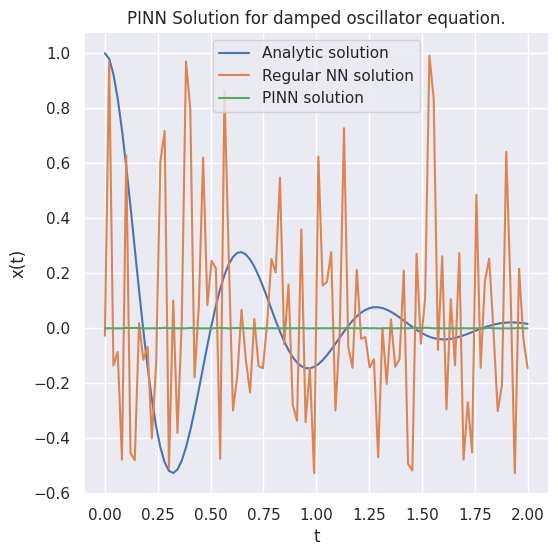

Epoch [21000/60000], NN Loss: 1.968169129895614e-07
Epoch [21000/60000], PINN Loss: 1.1709604263305664
Epoch [22000/60000], NN Loss: 1.702120044910771e-07
Epoch [22000/60000], PINN Loss: 1.1708933115005493
Epoch [23000/60000], NN Loss: 5.551523258873203e-07
Epoch [23000/60000], PINN Loss: 1.1710197925567627
Epoch [24000/60000], NN Loss: 1.5886320170466206e-07
Epoch [24000/60000], PINN Loss: 1.1707866191864014
Epoch [25000/60000], NN Loss: 2.3156383122113766e-07
Epoch [25000/60000], PINN Loss: 1.2039031982421875
Epoch [26000/60000], NN Loss: 2.138383479177719e-06
Epoch [26000/60000], PINN Loss: 1.1714550256729126
Epoch [27000/60000], NN Loss: 6.801341783102544e-07
Epoch [27000/60000], PINN Loss: 1.169459342956543
Epoch [28000/60000], NN Loss: 3.1035017400427023e-06
Epoch [28000/60000], PINN Loss: 1.157767653465271
Epoch [29000/60000], NN Loss: 1.3874632998067682e-07
Epoch [29000/60000], PINN Loss: 1.1387871503829956
Epoch [30000/60000], NN Loss: 4.140096052651643e-07
Epoch [30000/60000]

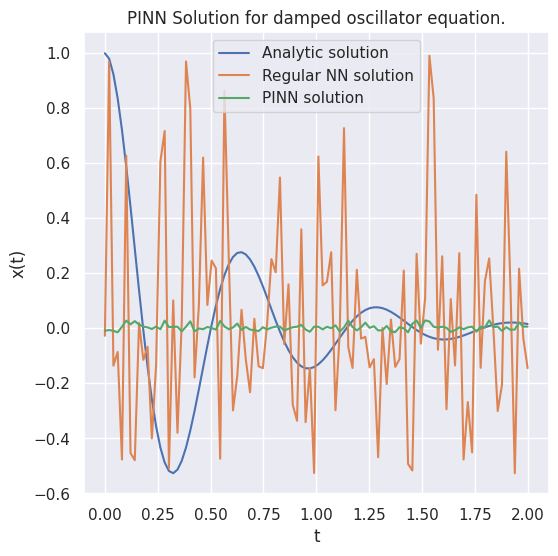

Epoch [31000/60000], NN Loss: 1.4103859768965776e-07
Epoch [31000/60000], PINN Loss: 1.1109447479248047
Epoch [32000/60000], NN Loss: 5.284311441755563e-07
Epoch [32000/60000], PINN Loss: 1.0889860391616821
Epoch [33000/60000], NN Loss: 8.797615919320378e-06
Epoch [33000/60000], PINN Loss: 1.0237112045288086


In [6]:
t_sample_nn.requires_grad = False
t_sample_pinn.requires_grad = False
x_sample_nn = x_sample_nn.detach()
x_sample_pinn = x_sample_pinn.detach()

for epoch in range(epochs):
    # zero optimizers
    nn_optimizer.zero_grad()
    pinn_optimizer.zero_grad()
    
    # compute forward 
    x_nn = nn_model(t_sample_nn)
    x_pinn = pinn_model(t_sample_pinn)
    
    # Compute the loss
    nn_loss = nn_model.data_loss(x_nn, x_sample_nn)
    pinn_loss = pinn_model.damped_oscillatior_loss(t) + pinn_model.boundary_condition_loss(t0, x0, dx0) + pinn_model.data_loss(x_pinn, x_sample_pinn)

    # Backpropagation
    nn_loss.backward()
    pinn_loss.backward()

    # keep losses
    losses.append(
        (
            torch.log(nn_loss).item(), 
            torch.log(pinn_loss).item()
        )
    )

    # step optimize
    nn_optimizer.step()
    pinn_optimizer.step()
    
    if epoch % 1000 == 0:
        print("="*50)
        print(f"Epoch [{epoch}/{epochs}], NN Loss: {nn_loss.item()}")
        print(f"Epoch [{epoch}/{epochs}], PINN Loss: {pinn_loss.item()}")

    # Plot the results
    if epoch % 10000 == 0:
        plt.figure(figsize=(6,6))
        plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
        plt.plot(t_test.detach().numpy(), x_nn.detach().numpy(), label="Regular NN solution")
        plt.plot(t_test.detach().numpy(), x_pinn.detach().numpy(), label="PINN solution")
        plt.xlabel('t')
        plt.ylabel('x(t)')
        plt.title('PINN Solution for damped oscillator equation.')
        plt.legend()
        plt.show()

# Plot the results
if epoch % 10000 == 0:
    plt.figure(figsize=(6,6))
    plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
    plt.plot(t_test.detach().numpy(), x_nn.detach().numpy(), label="Regular NN solution")
    plt.plot(t_test.detach().numpy(), x_pinn.detach().numpy(), label="PINN solution")
    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.title('PINN Solution for damped oscillator equation.')
    plt.legend()
    plt.show()

In [ ]:
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

In [ ]:
plt.figure()
plt.plot(losses[::200])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

In [ ]:


# Plot the results
plt.figure(figsize=(6,6))
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

In [ ]:
# alias to simplify notation
Z = model.ZETTA
w = model.W

# Test the model
t_test = 4*torch.linspace(-.2, 1.5, 100).reshape(-1, 1)
x_test = model(t_test)

root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = x0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# Plot the results
plt.figure(figsize=(6,6))
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.vlines([0, 2], [-2, -2], [3, 3], colors=["k", "k"], linestyles="dotted")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()